In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import sys
sys.path.append('..')

from data.emission_factors import SCOPE1, SCOPE2_ELECTRICITY, BIOMETHANE
from data.sites import LACQ, FRENCH_GAS_SECTOR_AVG

# Tell matplotlib to show charts inline in the notebook
%matplotlib inline

print("Visualisations notebook ready.")
print(f"Matplotlib version: {plt.matplotlib.__version__}")

Visualisations notebook ready.
Matplotlib version: 3.9.2


In [3]:
# ── FUNCTIONS ─────────────────────────────────────────────────────────────────
def calculate_scope1(site, ef_scope1):
    results = {}
    fuel_keys = {
        'natural_gas': 'natural_gas_MWh',
        'fuel_oil':    'fuel_oil_MWh',
        'coal':        'coal_MWh',
    }
    for fuel, site_key in fuel_keys.items():
        if site_key in site:
            results[fuel] = round(site[site_key] * ef_scope1[fuel], 1)
    if 'process_tCO2' in site:
        results['process_emissions'] = site['process_tCO2']
    results['TOTAL_scope1'] = round(sum(results.values()), 1)
    return results

def calculate_scope2(site, ef_electricity):
    grid = site['grid']
    ef   = ef_electricity[grid]
    mwh  = site['electricity_MWh']
    return {
        'location_based': round(mwh * ef, 1),
        'market_based':   round(mwh * ef_electricity['renewable_ppa'], 1),
        'grid_ef':        ef,
    }

def scenario_ppa(site, ef_electricity, ppa_fraction):
    assert 0.0 <= ppa_fraction <= 1.0
    grid            = site['grid']
    mwh             = site['electricity_MWh']
    ef_grid         = ef_electricity[grid]
    ef_ppa          = ef_electricity['renewable_ppa']
    ef_new          = (ppa_fraction * ef_ppa) + ((1 - ppa_fraction) * ef_grid)
    return {
        'scope2_new_tCO2': round(mwh * ef_new, 1),
        'reduction_tCO2':  round(mwh * ef_grid - mwh * ef_new, 1),
    }

def scenario_biomethane(site, ef_scope1, ef_biomethane,
                        bio_fraction, feedstock='agricultural_waste'):
    assert 0.0 <= bio_fraction <= 1.0
    ng_mwh        = site.get('natural_gas_MWh', 0)
    scope1_ng_new = ng_mwh * (1 - bio_fraction) * ef_scope1['natural_gas']
    scope1_bio    = ng_mwh * bio_fraction * ef_biomethane[feedstock]
    scope1_oil    = site.get('fuel_oil_MWh', 0) * ef_scope1['fuel_oil']
    scope1_new    = scope1_ng_new + scope1_bio + scope1_oil
    scope1_base   = (ng_mwh * ef_scope1['natural_gas'] +
                     site.get('fuel_oil_MWh', 0) * ef_scope1['fuel_oil'])
    return {
        'scope1_new_tCO2': round(scope1_new, 1),
        'reduction_tCO2':  round(scope1_base - scope1_new, 1),
    }

def scenario_ccs(scope1_residual_tCO2, capture_rate=0.90):
    assert 0.0 <= capture_rate <= 1.0
    return {
        'captured_tCO2': round(scope1_residual_tCO2 * capture_rate, 1),
        'residual_tCO2': round(scope1_residual_tCO2 * (1 - capture_rate), 1),
    }

def build_trajectory(site, ef_scope1, ef_elec, ef_bio, deployment_plan):
    scope1_base = (site.get('natural_gas_MWh', 0) * ef_scope1['natural_gas'] +
                   site.get('fuel_oil_MWh', 0) * ef_scope1['fuel_oil'])
    scope2_base = site['electricity_MWh'] * ef_elec[site['grid']]
    baseline    = scope1_base + scope2_base
    rows = []
    for year in sorted(deployment_plan.keys()):
        plan     = deployment_plan[year]
        scope2_y = scenario_ppa(site, ef_elec, plan.get('ppa', 0))['scope2_new_tCO2']
        scope1_y = scenario_biomethane(site, ef_scope1, ef_bio,
                                       plan.get('bio', 0))['scope1_new_tCO2']
        if plan.get('ccs', False):
            scope1_y = scenario_ccs(scope1_y)['residual_tCO2']
        total_y = scope1_y + scope2_y
        rows.append({
            'year':          year,
            'scope1':        round(scope1_y, 0),
            'scope2':        round(scope2_y, 0),
            'total':         round(total_y, 0),
            'reduction_pct': round((baseline - total_y) / baseline * 100, 1),
        })
    return pd.DataFrame(rows).set_index('year'), baseline

# Run baseline and scenarios
scope1       = calculate_scope1(LACQ, SCOPE1)
scope2       = calculate_scope2(LACQ, SCOPE2_ELECTRICITY)
baseline     = scope1['TOTAL_scope1'] + scope2['location_based']

ppa_100      = scenario_ppa(LACQ, SCOPE2_ELECTRICITY, ppa_fraction=1.00)
bio_40       = scenario_biomethane(LACQ, SCOPE1, BIOMETHANE, bio_fraction=0.40)
ccs_90       = scenario_ccs(bio_40['scope1_new_tCO2'], capture_rate=0.90)

LACQ_PLAN = {
    2024: {'ppa': 0.00, 'bio': 0.00, 'ccs': False},
    2026: {'ppa': 0.25, 'bio': 0.10, 'ccs': False},
    2028: {'ppa': 0.50, 'bio': 0.20, 'ccs': False},
    2030: {'ppa': 1.00, 'bio': 0.40, 'ccs': False},
    2035: {'ppa': 1.00, 'bio': 0.60, 'ccs': True },
    2040: {'ppa': 1.00, 'bio': 0.70, 'ccs': True },
    2050: {'ppa': 1.00, 'bio': 0.80, 'ccs': True },
}

traj, baseline_traj = build_trajectory(LACQ, SCOPE1, SCOPE2_ELECTRICITY,
                                        BIOMETHANE, LACQ_PLAN)

print(f"Baseline: {baseline:,.0f} tCO2eq/year")
print(f"All data ready for visualisation.")

Baseline: 211,550 tCO2eq/year
All data ready for visualisation.


Saved to ../outputs/lacq_baseline.png


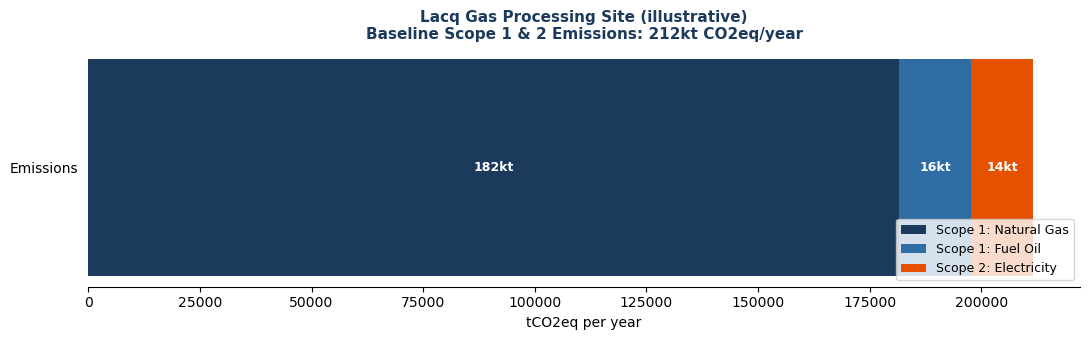

In [5]:
# ── CHART 1: BASELINE SCOPE 1 AND 2 BREAKDOWN ────────────────────────────────

def plot_baseline_breakdown(scope1_results, scope2_results, site_name, save_path=None):
    """Stacked horizontal bar showing Scope 1 by fuel and Scope 2."""

    fig, ax = plt.subplots(figsize=(11, 3.5))

    # Colours
    colours_s1 = ['#1B3A5C', '#2E6DA4', '#5B9BD5']
    colour_s2  = '#E65100'

    # Prepare Scope 1 data — exclude the TOTAL key
    s1_items = {k: v for k, v in scope1_results.items() if k != 'TOTAL_scope1'}

    # Plot Scope 1 segments
    left = 0
    for i, (label, val) in enumerate(s1_items.items()):
        ax.barh('Emissions', val, left=left,
                color=colours_s1[i % len(colours_s1)],
                label=f'Scope 1: {label.replace("_", " ").title()}')
        if val > 8000:
            ax.text(left + val / 2, 0, f'{val/1000:.0f}kt',
                    ha='center', va='center',
                    color='white', fontsize=9, fontweight='bold')
        left += val

    # Plot Scope 2
    s2_val = scope2_results['location_based']
    ax.barh('Emissions', s2_val, left=left,
            color=colour_s2, label='Scope 2: Electricity')
    ax.text(left + s2_val / 2, 0, f'{s2_val/1000:.0f}kt',
            ha='center', va='center',
            color='white', fontsize=9, fontweight='bold')

    total = sum(s1_items.values()) + s2_val
    ax.set_xlabel('tCO2eq per year', fontsize=10)
    ax.set_title(f'{site_name}\nBaseline Scope 1 & 2 Emissions: {total/1000:.0f}kt CO2eq/year',
                 fontsize=11, fontweight='bold', color='#1B3A5C')
    ax.legend(loc='lower right', fontsize=9)
    ax.set_xlim(0, total * 1.05)
    ax.spines[['top', 'right', 'left']].set_visible(False)
    ax.tick_params(left=False)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Saved to {save_path}")
    plt.show()

plot_baseline_breakdown(scope1, scope2,
                        site_name=LACQ['name'],
                        save_path='../outputs/lacq_baseline.png')

Saved to ../outputs/lacq_waterfall.png


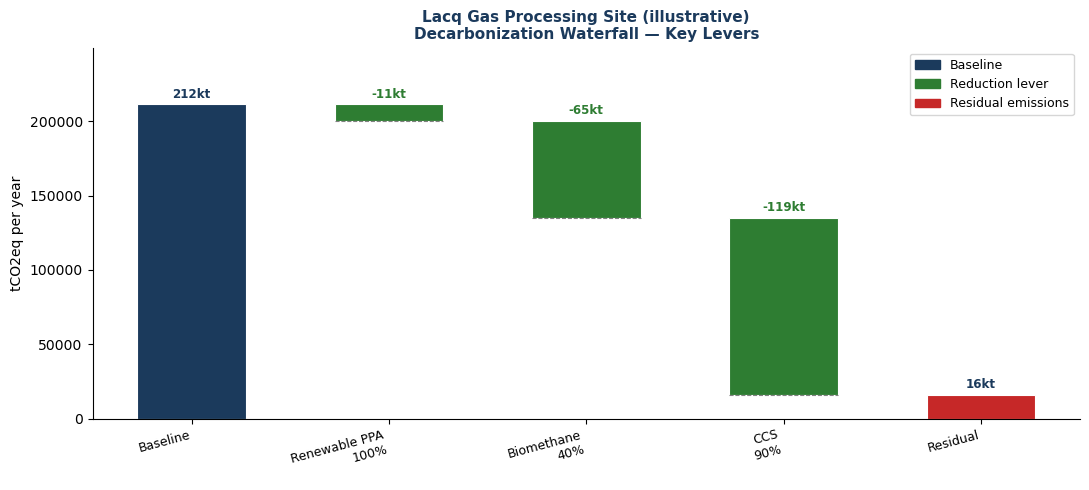

In [7]:
# ── CHART 2: WATERFALL CHART ──────────────────────────────────────────────────

def plot_waterfall(baseline, reductions, labels, site_name, save_path=None):
    """
    Waterfall chart showing each lever's contribution to abatement.
    baseline:   starting emissions in tCO2eq
    reductions: list of positive floats (savings from each lever)
    labels:     list of strings naming each lever
    """
    fig, ax = plt.subplots(figsize=(11, 5))

    all_labels  = ['Baseline'] + labels + ['Residual']
    n           = len(all_labels)
    bottoms     = []
    heights     = []
    bar_colours = []

    # Baseline bar — starts at zero, full height
    bottoms.append(0)
    heights.append(baseline)
    bar_colours.append('#1B3A5C')
    running = baseline

    # Reduction bars — float downward from previous level
    for red in reductions:
        running -= red
        bottoms.append(running)
        heights.append(red)
        bar_colours.append('#2E7D32')

    # Final residual bar — starts at zero, shows what remains
    bottoms.append(0)
    heights.append(running)
    bar_colours.append('#C62828')

    x    = np.arange(n)
    bars = ax.bar(x, heights, bottom=bottoms, color=bar_colours,
                  width=0.55, edgecolor='white', linewidth=0.8)

    # Value labels above each bar
    for i, (bar, bot, hgt) in enumerate(zip(bars, bottoms, heights)):
        top   = bot + hgt
        label = f'{top/1000:.0f}kt' if i == 0 or i == n - 1 else f'-{hgt/1000:.0f}kt'
        ax.text(bar.get_x() + bar.get_width() / 2,
                top + baseline * 0.012, label,
                ha='center', va='bottom', fontsize=8.5, fontweight='bold',
                color='#1B3A5C' if i == 0 or i == n - 1 else '#2E7D32')

    # Connector lines between reduction bars
    for i in range(1, n - 1):
        ax.plot([i - 0.275, i + 0.275],
                [bottoms[i], bottoms[i]],
                color='grey', linewidth=0.8, linestyle='--')

    # Legend
    legend_elements = [
        mpatches.Patch(color='#1B3A5C', label='Baseline'),
        mpatches.Patch(color='#2E7D32', label='Reduction lever'),
        mpatches.Patch(color='#C62828', label='Residual emissions'),
    ]
    ax.legend(handles=legend_elements, fontsize=9, loc='upper right')

    ax.set_xticks(x)
    ax.set_xticklabels(all_labels, rotation=15, ha='right', fontsize=9)
    ax.set_ylabel('tCO2eq per year', fontsize=10)
    ax.set_title(f'{site_name}\nDecarbonization Waterfall — Key Levers',
                 fontsize=11, fontweight='bold', color='#1B3A5C')
    ax.set_ylim(0, baseline * 1.18)
    ax.spines[['top', 'right']].set_visible(False)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Saved to {save_path}")
    plt.show()

plot_waterfall(
    baseline   = baseline,
    reductions = [
        ppa_100['reduction_tCO2'],
        bio_40['reduction_tCO2'],
        ccs_90['captured_tCO2'],
    ],
    labels     = ['Renewable PPA\n100%', 'Biomethane\n40%', 'CCS\n90%'],
    site_name  = LACQ['name'],
    save_path  = '../outputs/lacq_waterfall.png'
)

Saved to ../outputs/lacq_trajectory.png


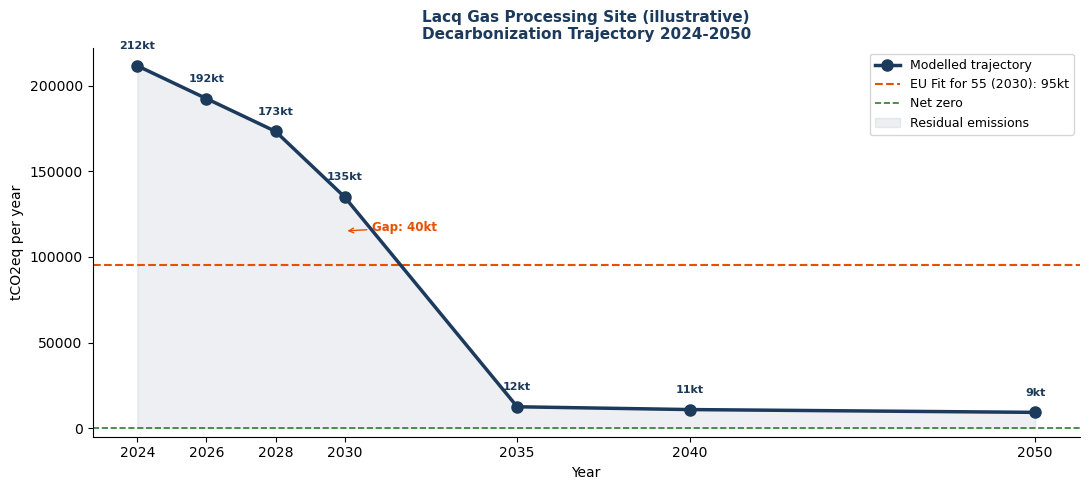

In [9]:
# ── CHART 3: DECARBONIZATION TRAJECTORY ──────────────────────────────────────

def plot_trajectory(traj_df, baseline, site_name, save_path=None):
    """
    Line chart of annual emissions vs EU 2030 and net-zero targets.
    """
    fig, ax = plt.subplots(figsize=(11, 5))

    years  = traj_df.index.tolist()
    totals = traj_df['total'].tolist()

    # Main trajectory line
    ax.plot(years, totals, 'o-', color='#1B3A5C',
            linewidth=2.5, markersize=8,
            label='Modelled trajectory', zorder=5)

    # EU Fit for 55 target line — 55% reduction by 2030
    target_2030 = baseline * 0.45
    ax.axhline(target_2030, color='#E65100', linestyle='--',
               linewidth=1.5, label=f'EU Fit for 55 (2030): {target_2030/1000:.0f}kt')

    # Net zero reference line
    ax.axhline(0, color='#2E7D32', linestyle='--',
               linewidth=1.2, label='Net zero')

    # Shade residual emissions area
    ax.fill_between(years, totals, 0,
                    alpha=0.08, color='#1B3A5C',
                    label='Residual emissions')

    # Annotate each data point
    for year, val in zip(years, totals):
        ax.annotate(f'{val/1000:.0f}kt',
                    xy=(year, val), xytext=(0, 12),
                    textcoords='offset points',
                    ha='center', fontsize=8, color='#1B3A5C',
                    fontweight='bold')

    # 2030 gap annotation
    modelled_2030 = traj_df.loc[2030, 'total']
    gap           = modelled_2030 - target_2030
    ax.annotate(f'Gap: {gap/1000:.0f}kt',
                xy=(2030, (modelled_2030 + target_2030) / 2),
                xytext=(20, 0), textcoords='offset points',
                color='#E65100', fontsize=8.5, fontweight='bold',
                arrowprops=dict(arrowstyle='->', color='#E65100'))

    ax.set_xlabel('Year', fontsize=10)
    ax.set_ylabel('tCO2eq per year', fontsize=10)
    ax.set_title(f'{site_name}\nDecarbonization Trajectory 2024-2050',
                 fontsize=11, fontweight='bold', color='#1B3A5C')
    ax.legend(fontsize=9, loc='upper right')
    ax.set_ylim(bottom=-5000)
    ax.set_xticks(years)
    ax.spines[['top', 'right']].set_visible(False)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Saved to {save_path}")
    plt.show()

plot_trajectory(traj, baseline_traj,
                site_name=LACQ['name'],
                save_path='../outputs/lacq_trajectory.png')